Import packages

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cobra
from cobra.io import read_sbml_model, write_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from tqdm import tqdm

In [2]:
from pathlib import Path
import plotly
import plotly.express as px
import scipy.stats

os.environ["OMP_NUM_THREADS"] = "1"  # because of a data leak of KMeans on windows
import fba_comparison_stats as cmp
from efflux_method import *
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

In [ ]:
table = pd.read_csv("/home/mickael/github/M_xanthus-E_coli-Predation/data/Raw/WT_vs_4preys_RIPTiDe.csv")
table.set_index("GeneNames", inplace=True)

In [ ]:
table.corr()

,Ec1,Ec2,Ec3,B1,B2,B3,C1,C2,C3,Y1,...,W3,K1,K2,K3,WC1,WC2,WC3,KC1,KC2,KC3
Ec1,1.000000,0.968995,0.937906,0.972749,0.969625,0.914176,0.914936,0.906303,0.913233,0.887547,...,0.782695,0.793274,0.796777,0.782234,0.708432,0.692272,0.779508,0.500804,0.663639,0.578153
Ec2,0.968995,1.000000,0.978197,0.934636,0.947817,0.843680,0.875137,0.925230,0.875138,0.884889,...,0.788704,0.768716,0.788043,0.752694,0.683772,0.703797,0.757646,0.520501,0.676548,0.568213
Ec3,0.937906,0.978197,1.000000,0.909243,0.919928,0.806393,0.824667,0.892809,0.819892,0.864344,...,0.804885,0.745334,0.770833,0.710687,0.696607,0.736337,0.750268,0.588954,0.718862,0.581460
B1,0.972749,0.934636,0.909243,1.000000,0.981634,0.949993,0.945318,0.909903,0.938607,0.910277,...,0.830779,0.836848,0.834620,0.832051,0.770295,0.741859,0.840801,0.532954,0.702349,0.632454
B2,0.969625,0.947817,0.919928,0.981634,1.000000,0.941838,0.951038,0.944823,0.944599,0.929618,...,0.854008,0.847019,0.854903,0.838708,0.764988,0.753275,0.848127,0.559171,0.714211,0.627261
B3,0.914176,0.843680,0.806393,0.949993,0.941838,1.000000,0.943827,0.859134,0.944039,0.889452,...,0.820639,0.862020,0.844586,0.869438,0.794877,0.724616,0.858050,0.516032,0.685758,0.648963
C1,0.914936,0.875137,0.824667,0.945318,0.951038,0.943827,1.000000,0.940390,0.991175,0.910023,...,0.823686,0.829719,0.819504,0.837021,0.743173,0.710790,0.829748,0.491007,0.634133,0.564708
C2,0.906303,0.925230,0.892809,0.909903,0.944823,0.859134,0.940390,1.000000,0.941037,0.918112,...,0.843909,0.810714,0.826431,0.804938,0.711571,0.736620,0.816491,0.551436,0.665972,0.555221
C3,0.913233,0.875138,0.819892,0.938607,0.944599,0.944039,0.991175,0.941037,1.000000,0.916218,...,0.822589,0.840579,0.831770,0.854536,0.745123,0.708024,0.838730,0.481439,0.633523,0.572699
Y1,0.887547,0.884889,0.864344,0.910277,0.929618,0.889452,0.910023,0.918112,0.916218,1.000000,...,0.909825,0.904696,0.909859,0.887583,0.818236,0.806952,0.900764,0.591179,0.763982,0.656763


Import the models

How to make each models, how to put information in it? Efflux?

In [3]:
M_xanthus = read_sbml_model("../M_xanthus_model_V4.xml")

In [ ]:
list_of_genes = []
for i in M_xanthus.genes:
    list_of_genes.append(i.id)

In [ ]:
# Getting fluxes with constrains
dico = {
    14: "Alone",
    2: "P_E_coli_1-3",
    5: "P_B_subtilis",
    8: "P_Caulobacter",
    20: "P_E_coli_1-1",
}
for i in [14, 2, 5, 8, 20]:
    M_xanthus = read_sbml_model("../M_xanthus_model_V4.xml")
    DictAP = read_csv_data(
        "/home/mickael/github/M_xanthus-E_coli-Predation/data/Raw/WT_vs_4preys_iMAT.csv",
        id_gene=1,
        id_val=i,
        list_of_genes=list_of_genes,
        head=True,
        quantile=0.95,
    )
    Eflux(M_xanthus, DictAP, const=100, default_exp_val=1, ignore_human=True)
    M_xanthus.reactions.EX_glc_D_e.bounds = (0, 1000)
    model_c = M_xanthus.copy()
    write_sbml_model(
        model_c,
        "/home/mickael/github/M_xanthus-E_coli-Predation/fba_comparer-main/Models_Preda/M_xanthus_V4_efflux_"
        + dico[i]
        + ".xml",
    )
    print(dico[i] + " Done!")

KeyboardInterrupt: 

In [4]:
M_xanthus_alone = read_sbml_model("Models_Preda/M_xanthus_V4_efflux_Alone.xml")
solution_alone = M_xanthus_alone.optimize()

In [5]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-3.xml"
)
solution_predation_E_3 = M_xanthus_predation.optimize()

In [6]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_B_subtilis.xml"
)
solution_predation_B = M_xanthus_predation.optimize()

In [7]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_Caulobacter.xml"
)
solution_predation_C = M_xanthus_predation.optimize()

In [8]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-1.xml"
)
solution_predation_E_1 = M_xanthus_predation.optimize()

In [9]:
print(f"Alone:\t{solution_alone.objective_value}")
print(f"Predation E.coli 1/1 :\t{solution_predation_E_1.objective_value}")
print(f"Predation E.coli 1/3 :\t{solution_predation_E_3.objective_value}")
print(f"Predation B_subtilis:\t{solution_predation_B.objective_value}")
print(f"Predation Caulobacter:\t{solution_predation_C.objective_value}")

Alone:	0.204452758536134
Predation E.coli 1/1 :	0.16754778715563926
Predation E.coli 1/3 :	0.10165517381424201
Predation B_subtilis:	0.15158979104534828
Predation Caulobacter:	0.16752521568295686


## **FBA Comparer**
**Create combined dataframe and preprocess data**

Filter all reactions where fluxes are zero:

In [10]:
solutions = [
    solution_alone,
    solution_predation_E_1,
    solution_predation_E_3,
    solution_predation_B,
    solution_predation_C,
]
conditions = [
    "Alone",
    "Predation E.coli 1/1",
    "Predation E.coli 1/3",
    "Predation B. subtilis",
    "Predation Caulobacter",
]
obj_values = [
    solution_alone.objective_value,
    solution_predation_E_1.objective_value,
    solution_predation_E_3.objective_value,
    solution_predation_B.objective_value,
    solution_predation_C.objective_value,
]

mxanthus = cmp.build_dataframe(M_xanthus_alone, solutions, conditions)
mxanthus_filtered = cmp.filter_dataframe(mxanthus, conditions, rounding=True)
print(f"Number of reactions in the models: {len(mxanthus)}")
print(f"Number of nonzero reactions in the models: {len(mxanthus_filtered)}")

Number of reactions in the models: 1339
Number of nonzero reactions in the models: 447


normalize data:

In [11]:
mxanthus_normalized = cmp.normalize_dataframe_cols(
    mxanthus_filtered, conditions, obj_values
)  # biomass normalization
mxanthus_normalized_div_by_max = cmp.normalize_dataframe_rows(
    mxanthus_normalized, conditions, "div_by_max"
)  # normalization reactions
# note: there is no difference between the order of div_by_max normalization and filtering for changing reactions
mxanthus_normalized_div_by_max_changing = mxanthus_normalized_div_by_max[
    mxanthus_normalized_div_by_max["Std_dev"] >= 0.01
]  # keep only reactions that change
print(
    f"Number of normalized changing reactions: {len(mxanthus_normalized_div_by_max_changing)}"
)

Number of normalized changing reactions: 205


## Identify reactions with most/least variation

Most affected / change reaction

In [12]:
most_variable_bar_plot = cmp.bar_plot_flux_variation(
    mxanthus_normalized, conditions, 0, 10
)
most_variable_bar_plot.show()

In [13]:
sorted_flux = mxanthus_normalized[["ID", "Name", "Std_dev"]].sort_values(
    by=["Std_dev"], ascending=False
)
sorted_flux["Kegg"] = [
    M_xanthus_alone.reactions.get_by_id(id).__dict__["_annotation"].get("kegg.reaction")
    for id in sorted_flux["ID"]
]
sorted_flux[0:20]

,ID,Name,Std_dev,Kegg
842,rxn01507_c,2'-Deoxyadenosine 5'-monophosphate phosphohydr...,9.871927,R02088
583,rxn01508_c,ATP:deoxyadenosine 5'-phosphotransferase [c],9.871927,R02089
909,rxn00119_c,ATP:UMP phosphotransferase [c],4.142052,R00158
716,rxn01366_c,Uridine:phosphate alpha-D-ribosyltransferase [c],4.010067,R01876
910,rxn00709_c,ATP:uridine 5'-phosphotransferase [c],4.010067,R00964
1261,EX_pi_e,Exchange for Phosphate [e],3.814328,None
672,rxn05312_c,Inorganic phosphate transporter [c],3.814328,None
1067,rxn00117_c,ATP:UDP phosphotransferase [c],3.365245,R00156
352,rxn00463_c,Uridine triphosphate pyrophosphohydrolase [c],3.365245,R00662
499,rxn00711_c,UMP:diphosphate phospho-alpha-D-ribosyltransfe...,2.868607,R00966


Pathway analysis

In [14]:
from bioservices import KEGG

k = KEGG()

for rxn in M_xanthus.reactions:
    if "kegg.reaction" in rxn.annotation:
        kegg_id = rxn.annotation["kegg.reaction"]
        try:
            data = k.get(kegg_id)
            parsed = k.parse(data)
            if "PATHWAY" in parsed:
                rxn.subsystem = list(parsed["PATHWAY"].values())[0]
        except:
            continue

WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02371)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R01549)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02097)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02292)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00962)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00967)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https

In [15]:
pathway_dict_M = {}
for i in M_xanthus.reactions:
    if i.subsystem in pathway_dict_M:
        pathway_dict_M[i.subsystem].append(i.id)
    else:
        pathway_dict_M[i.subsystem] = [i.id]

In [16]:
pw_list = cmp.pathway_variability(
    mxanthus_normalized, pathway_dict_M, ascending=True, num=20
)

Purine metabolism		 -> 1.39 (contains 35 reactions)
Pyrimidine metabolism		 -> 1.23 (contains 25 reactions)
Glycerophospholipid metabolism		 -> 0.77 (contains 1 reactions)
Glycolysis / Gluconeogenesis		 -> 0.70 (contains 6 reactions)
Arginine biosynthesis		 -> 0.50 (contains 7 reactions)
Citrate cycle (TCA cycle)		 -> 0.42 (contains 8 reactions)
Metabolic pathways		 -> 0.40 (contains 1 reactions)
Alanine, aspartate and glutamate metabolism		 -> 0.25 (contains 4 reactions)
Pyruvate metabolism		 -> 0.21 (contains 1 reactions)
		 -> 0.20 (contains 154 reactions)
Glyoxylate and dicarboxylate metabolism		 -> 0.19 (contains 3 reactions)
Phenylalanine metabolism		 -> 0.13 (contains 2 reactions)
Monobactam biosynthesis		 -> 0.12 (contains 3 reactions)
Glycine, serine and threonine metabolism		 -> 0.11 (contains 9 reactions)
Fatty acid elongation		 -> 0.10 (contains 6 reactions)
Fatty acid degradation		 -> 0.10 (contains 1 reactions)
Lysine biosynthesis		 -> 0.08 (contains 6 reactions)
Cysteine

In [17]:
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Purine metabolism":
        print(i)

rxn00836_c
rxn01358_c
rxn00800_c
rxn03039_c
rxn01297_c
rxn00361_c
rxn00242_c
rxn00514_c
rxn00097_c
rxn00913_c
rxn01445_c
rxn00917_c
rxn01444_c
rxn00139_c
rxn00790_c
rxn00237_c
rxn00132_c
rxn00838_c
rxn00831_c
rxn01509_c
rxn01548_c
rxn00915_c
rxn03147_c
rxn01544_c
rxn01138_c
rxn00832_c
rxn05115_c
rxn00515_c
rxn01353_c
rxn00775_c
rxn02895_c
rxn01508_c
rxn05231_c
rxn00379_c
rxn00307_c
rxn00303_c
rxn00065_c
rxn03136_c
rxn02937_c
rxn03137_c
rxn01961_c
rxn01127_c
rxn00834_c
rxn00241_c
rxn01351_c
rxn03084_c
rxn01859_c
rxn01507_c
rxn01446_c
rxn00301_c
rxn05233_c
rxn01649_c
rxn00063_c
rxn01225_c
rxn02518_c
rxn01985_c
rxn02517_c
rxn05114_c
rxn03004_c
rxn01858_c
rxn00239_c
rxn01137_c
rxn00839_c


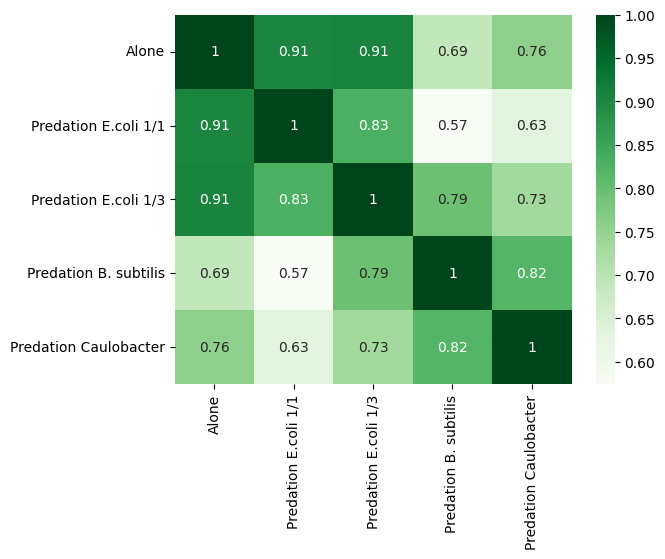

In [18]:
fig_r = cmp.correlation_matrix(
    mxanthus_normalized_div_by_max_changing, conditions, color="Greens"
)

## Flux correlation network

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
corr_matrix = cmp.flux_coupling_matrix(
    mxanthus_normalized_div_by_max, conditions, remove_unchanging=0.01, abs_values=True
)

242 reaction were removed, because their Std_dev is lower than 0.01


In [21]:
mask = []
for i in corr_matrix:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Purine metabolism":
        mask.append(i)

new = corr_matrix.filter(mask, axis=0)
corr_matrix_filter = new.filter(mask, axis=1)

corr_matrix_filter

,rxn00836_c,rxn01358_c,rxn00800_c,rxn00097_c,rxn00913_c,rxn00917_c,rxn01444_c,rxn00237_c,rxn00132_c,rxn00838_c,...,rxn01548_c,rxn01544_c,rxn00832_c,rxn01508_c,rxn03137_c,rxn01507_c,rxn01446_c,rxn05233_c,rxn01225_c,rxn01137_c
rxn00836_c,1.000000,1.000000,0.355859,-0.923738,0.642687,0.768036,0.400286,0.277995,0.377055,0.355859,...,0.642687,0.768036,0.882124,-0.291913,0.882124,-0.291913,0.400286,0.400286,0.768036,0.376030
rxn01358_c,1.000000,1.000000,0.355859,-0.923738,0.642687,0.768036,0.400286,0.277995,0.377055,0.355859,...,0.642687,0.768036,0.882124,-0.291913,0.882124,-0.291913,0.400286,0.400286,0.768036,0.376030
rxn00800_c,0.355859,0.355859,1.000000,-0.521797,0.781739,0.361537,0.864699,0.992617,0.999702,1.000000,...,0.781739,0.361537,0.686197,-0.971236,0.686197,-0.971236,0.864699,0.864699,0.361537,0.999733
rxn00097_c,-0.923738,-0.923738,-0.521797,1.000000,-0.709452,-0.868123,-0.428477,-0.427623,-0.542231,-0.521797,...,-0.709452,-0.868123,-0.975342,0.429729,-0.975342,0.429729,-0.428477,-0.428477,-0.868123,-0.541267
rxn00913_c,0.642687,0.642687,0.781739,-0.709452,1.000000,0.766259,0.905710,0.764139,0.791922,0.781739,...,1.000000,0.766259,0.830025,-0.840505,0.830025,-0.840505,0.905710,0.905710,0.766259,0.790857
rxn00917_c,0.768036,0.768036,0.361537,-0.868123,0.766259,1.000000,0.421641,0.285096,0.382097,0.361537,...,0.766259,1.000000,0.850447,-0.366457,0.850447,-0.366457,0.421641,0.421641,1.000000,0.380577
rxn01444_c,0.400286,0.400286,0.864699,-0.428477,0.905710,0.421641,1.000000,0.890292,0.865507,0.864699,...,0.905710,0.421641,0.610295,-0.944387,0.610295,-0.944387,1.000000,1.000000,0.421641,0.865007
rxn00237_c,0.277995,0.277995,0.992617,-0.427623,0.764139,0.285096,0.890292,1.000000,0.989948,0.992617,...,0.764139,0.285096,0.608518,-0.984538,0.608518,-0.984538,0.890292,0.890292,0.285096,0.990045
rxn00132_c,0.377055,0.377055,0.999702,-0.542231,0.791922,0.382097,0.865507,0.989948,1.000000,0.999702,...,0.791922,0.382097,0.703728,-0.969575,0.703728,-0.969575,0.865507,0.865507,0.382097,0.999998
rxn00838_c,0.355859,0.355859,1.000000,-0.521797,0.781739,0.361537,0.864699,0.992617,0.999702,1.000000,...,0.781739,0.361537,0.686197,-0.971236,0.686197,-0.971236,0.864699,0.864699,0.361537,0.999733


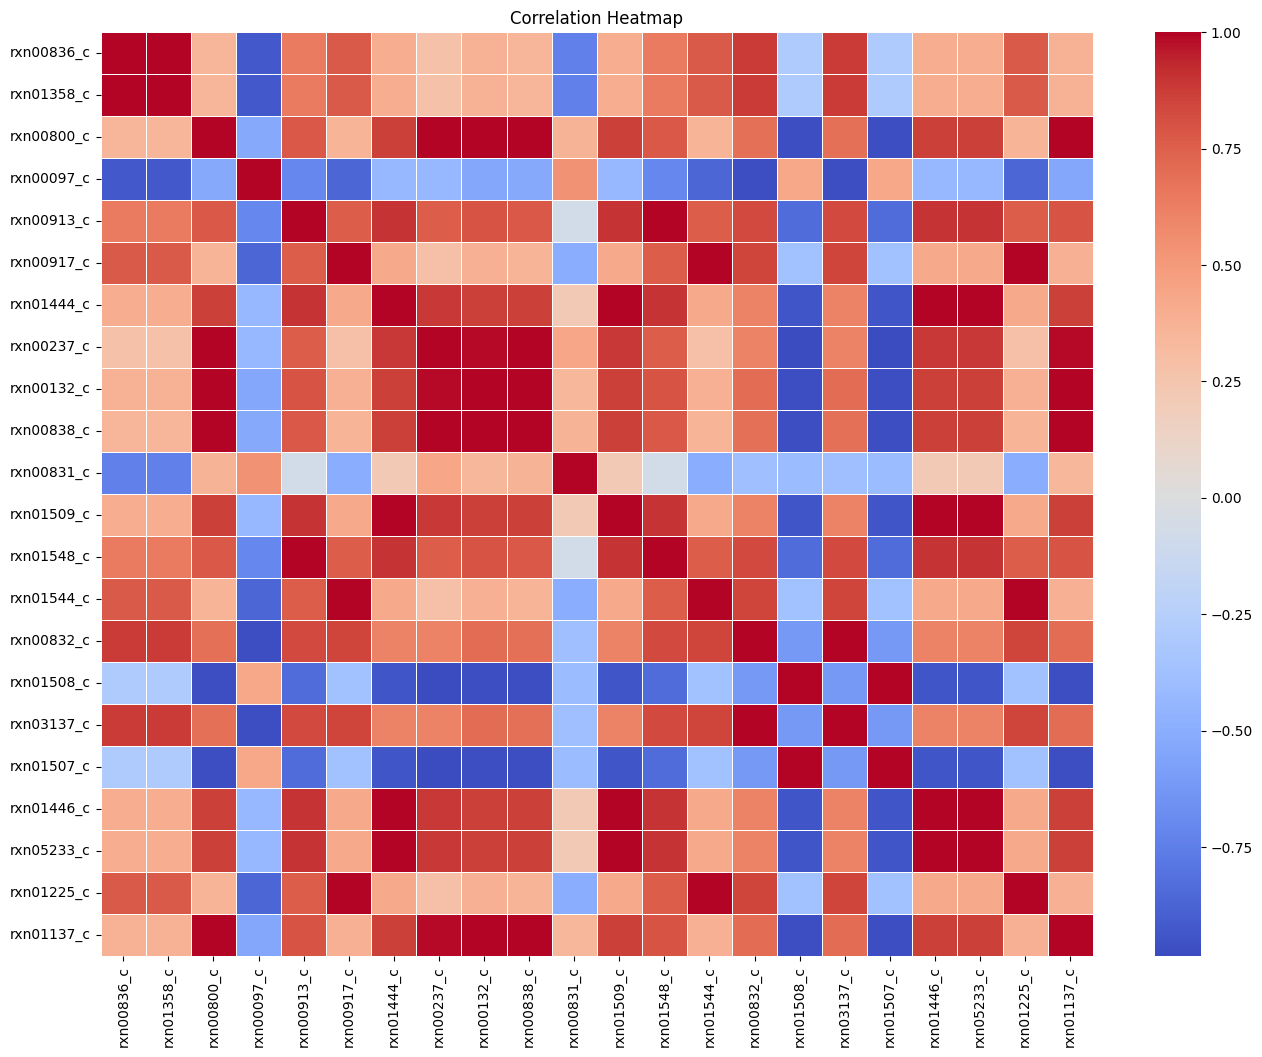

In [22]:
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix_filter, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Correlation network
nw = cmp.flux_coupling_network(corr_matrix, pc=0.7)
fig = cmp.visualize_interactive_network(nw, mxanthus_normalized_div_by_max, conditions)
fig.show()

Created Flux Coupling network with pc threshold 0.7.
Number of nodes: 205
Number of edges: 4062
Number of connected components: 5


In [219]:
# # Colored pathway network
# nw3 = nw
# cmp.color_network_by_pathway(
#     nw3, pathway= "Purine metabolism", pathway_dict= pathway_dict_M
# )  # takes edge weights into account!

# fig = cmp.visualize_interactive_network(nw3, mxanthus_normalized_div_by_max, conditions)
# fig.show()

In [ ]:
# Colored community network
nw2 = nw
cmp.color_network_by_communities(
    nw2, 8, include_weights=True
)  # takes edge weights into account!

comm_map = cmp.get_community_list(nw)
color = cmp.get_color_map(comm_map)

fig = cmp.visualize_interactive_network(nw2, mxanthus_normalized_div_by_max, conditions)
fig.show()

In [221]:
for i in comm_map:
    print(i)

#FD3216
#00FE35
#6A76FC
#FED4C4
#FE00CE
#0DF9FF
#F6F926
#FF9616
#479B55
#EEA6FB
#DC587D
#D626FF
#6E899C
#00B5F7
#B68E00
#C9FBE5
#FF0092


Look for community 1, 2 and 3

Try also for 7 and 10

In [222]:
# Community 1
Genes_list_1 = []
for i in comm_map["#FD3216"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_1:
            Genes_list_1.append(str(j))

with open('Genes_list_1.txt', 'w') as f:
    for line in Genes_list_1:
        f.write(f"{line}\n")

In [223]:
# Community 2
Genes_list_2 = []
for i in comm_map["#00FE35"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_2:
            Genes_list_2.append(str(j))

with open('Genes_list_2.txt', 'w') as f:
    for line in Genes_list_2:
        f.write(f"{line}\n")

In [224]:
# Community 5
Genes_list_5 = []
for i in comm_map["#FE00CE"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_5:
            Genes_list_5.append(str(j))

with open('Genes_list_5.txt', 'w') as f:
    for line in Genes_list_5:
        f.write(f"{line}\n")

In [225]:
# Community 7
Genes_list_7 = []
for i in comm_map["#F6F926"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_7:
            Genes_list_7.append(str(j))

with open('Genes_list_7.txt', 'w') as f:
    for line in Genes_list_7:
        f.write(f"{line}\n")

In [226]:
# Community 9
Genes_list_9 = []
for i in comm_map["#479B55"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_9:
            Genes_list_9.append(str(j))

with open('Genes_list_9.txt', 'w') as f:
    for line in Genes_list_9:
        f.write(f"{line}\n")

In [227]:
# Community 11
Genes_list_11 = []
for i in comm_map["#DC587D"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_11:
            Genes_list_11.append(str(j))

with open('Genes_list_11.txt', 'w') as f:
    for line in Genes_list_11:
        f.write(f"{line}\n")

Community map

In [228]:
fig = cmp.community_bar_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [229]:
fig = cmp.community_box_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()